In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [18]:
df = pd.read_csv("Resultado.csv")

In [19]:
df["Score"] = df["Score"].str.replace(",", ".").astype(float)
df["AOL"] = df["AOL"].str.replace(",", ".").astype(float)
df["Width Rib"] = df["Width Rib"].str.replace(",", ".").astype(float)
df["Width Ext Fat"] = df["Width Ext Fat"].str.replace(",", ".").astype(float)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39 entries, 0 to 38
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SEXO           36 non-null     object 
 1   MATURIDADE     36 non-null     float64
 2   ACABAMENTO     36 non-null     float64
 3   ITEM           36 non-null     float64
 4   PESO           36 non-null     float64
 5   ETIQUETA       37 non-null     object 
 6   FOTO           39 non-null     object 
 7   AOL            36 non-null     float64
 8   Width Rib      36 non-null     float64
 9   Width Ext Fat  36 non-null     float64
 10  Score          36 non-null     float64
dtypes: float64(8), object(3)
memory usage: 3.5+ KB


<Axes: >

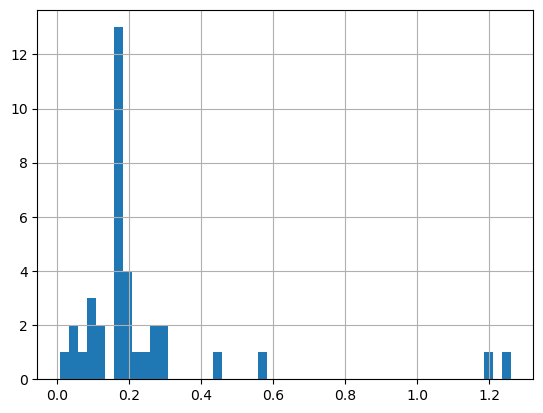

In [22]:
df["Width Ext Fat"].hist(bins=50)

In [34]:
print(df["PESO"].max())
print(df["PESO"].min())

173.0
129.0


<Axes: >

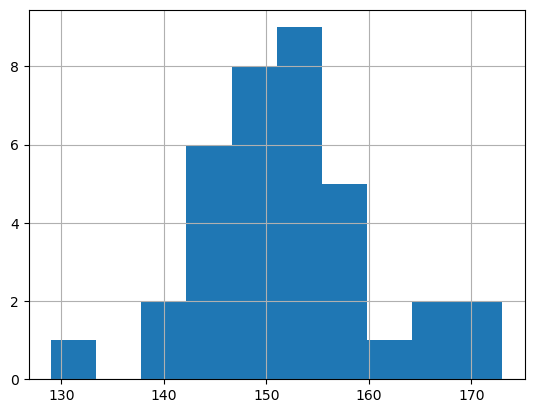

In [35]:
df["PESO"].hist(bins=10)

In [47]:
df.columns

Index(['SEXO', 'MATURIDADE', 'ACABAMENTO', 'ITEM', 'PESO', 'ETIQUETA', 'FOTO',
       'AOL', 'Width Rib', 'Width Ext Fat', 'Score'],
      dtype='object')

In [50]:
print(df[["PESO", "ACABAMENTO", "MATURIDADE"]].describe())

             PESO  ACABAMENTO  MATURIDADE
count   36.000000   36.000000   36.000000
mean   152.111111    3.694444    2.694444
std      8.824569    0.467177    1.064208
min    129.000000    3.000000    2.000000
25%    146.750000    3.000000    2.000000
50%    151.500000    4.000000    2.000000
75%    156.000000    4.000000    4.000000
max    173.000000    4.000000    6.000000


7


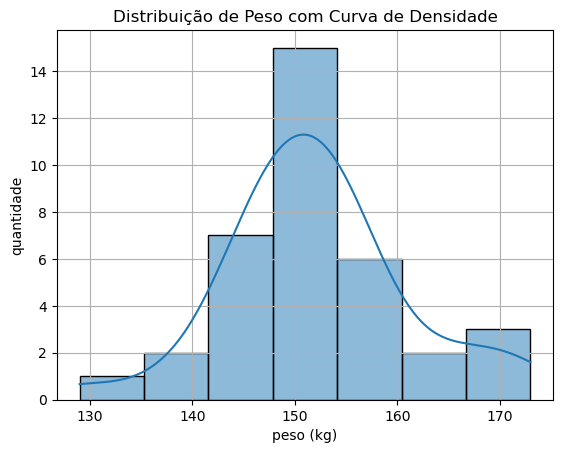

In [72]:
import seaborn as sns
import matplotlib.pyplot as plt

import numpy as np

data = df["PESO"].dropna()

q25, q75 = np.percentile(data, [25, 75])
iqr = q75 - q25
bin_width = 2 * iqr * len(data) ** (-1 / 3)
bins = int((data.max() - data.min()) / bin_width)
print(bins)
# Remove NaNs da coluna PESO, se houver

# Plotando histograma com curva de densidade
sns.histplot(data, kde=True, bins=bins, edgecolor="black")

plt.title("Distribuição de Peso" " com Curva de Densidade")
plt.xlabel("peso (kg)")
plt.ylabel("quantidade")
plt.grid(True)
plt.savefig(
    "./img/histograma_peso.png", dpi=300, bbox_inches="tight"
)  # <-- alta qualidade
plt.show()

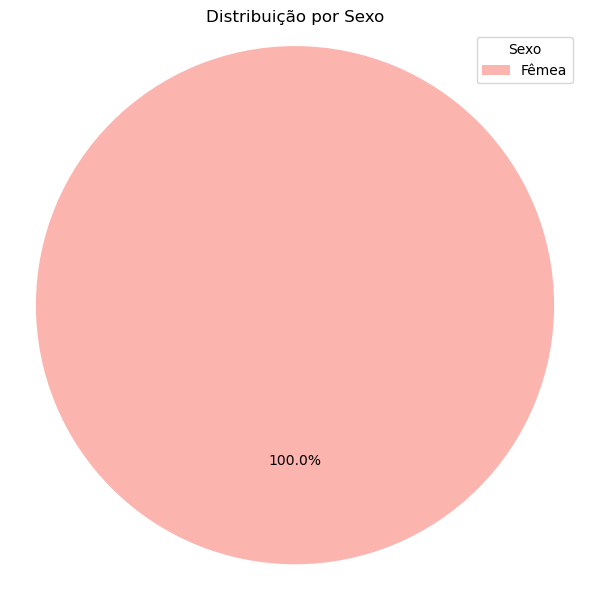

In [79]:
import matplotlib.pyplot as plt

# Contagem da coluna SEXO
data = df["SEXO"].value_counts()

# Mapeia rótulos para forma por extenso
label_map = {"F": "Fêmea", "M": "Macho"}
labels = [
    label_map.get(sex, sex) for sex in data.index
]  # Mantém outros valores se houver

sizes = data.values
colors = plt.cm.Pastel1.colors  # Paleta suave e agradável

plt.figure(figsize=(6, 6))
patches, texts, autotexts = plt.pie(
    sizes, labels=None, autopct="%1.1f%%", startangle=90, colors=colors
)

# Legenda com nomes por extenso
plt.legend(patches, labels, title="Sexo", loc="upper right")

plt.title("Distribuição por Sexo")
plt.axis("equal")  # Garante formato circular
plt.tight_layout()
plt.savefig("./img/pizza_sexo.png", dpi=300, bbox_inches="tight")  # <-- alta qualidade
plt.show()